In [6]:
import os
import pandas as pd
from nilearn import plotting
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

path ='/Users/barbaragrosjean/Desktop/SEEG_Musical_Memory'
os.path.exists(path)
subj_list=['HEJ023', 'HEJ022', 'HEJ025']
os.listdir(path)

['HEJ_Subject023_Block_1_EncodingRecognition.log',
 'HEJ022_Coordinates_and_Atlas.csv',
 'HEJ025_Coordinates_and_Atlas.csv',
 'HEJ023_Coordinates_and_Atlas.mat',
 'HEJ_Subject025_Block_1_EncodingRecognition.log',
 'HEJ025_20260211_MusicalMemory.edf',
 'HEJ025_Coordinates_and_Atlas.mat',
 'HEJ022_20251010_MusicalMemory.edf',
 'HEJ022_Coordinates_and_Atlas.mat',
 'HEJ_Subject022_Block_1_EncodingRecognition.log',
 'HEJ023_Coordinates_and_Atlas.csv',
 'HEJ023_20251210_MusicalMemory.edf']

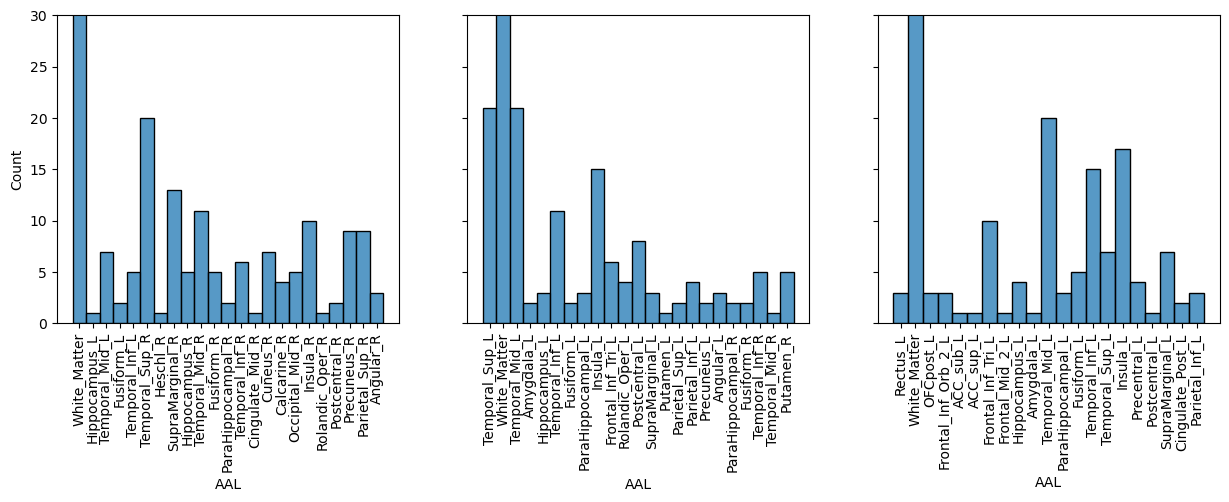

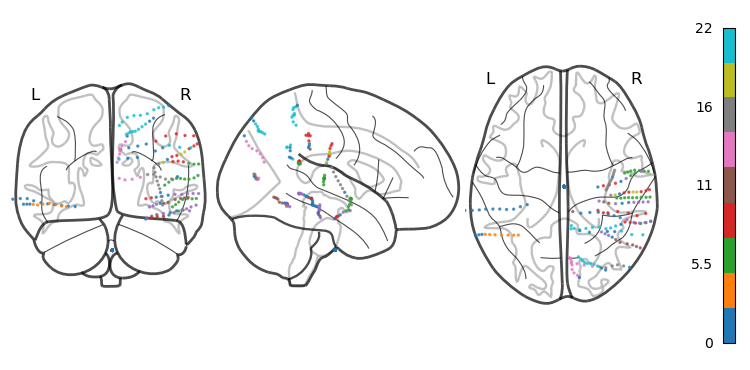

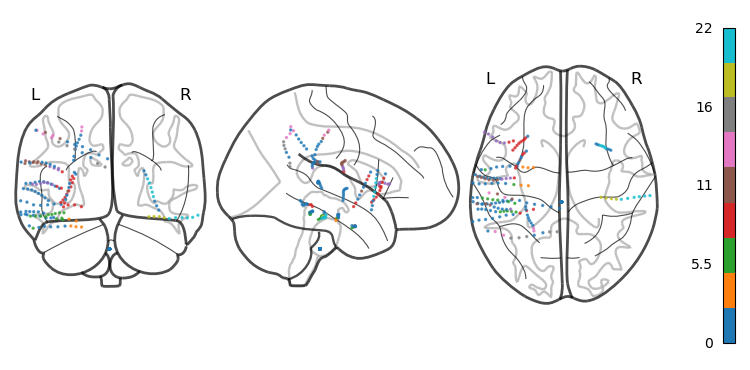

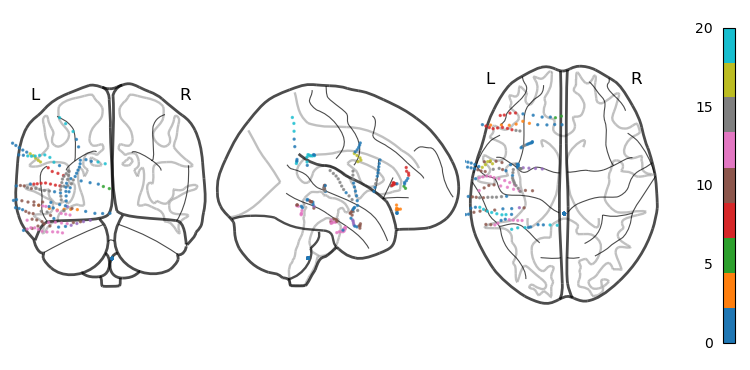

In [22]:
# Get the log file 
with open(path + "/HEJ_Subject023_Block_1_EncodingRecognition.log", "r") as f:
    log = f.read()

# Get the coordinate
fig, ax=plt.subplots(1, 3, sharey=True, figsize=(15, 4))

for isubj, subj in enumerate(subj_list) : 
    df=pd.read_csv(path + f'/{subj}_Coordinates_and_Atlas.csv')
    coordinates = df[['MNICoordinate_1', 'MNICoordinate_2', 'MNICoordinate_3']].values
    code_area_AAL = pd.factorize(df.loc[:, "AAL"])[0]
    fig = plotting.plot_markers(node_values=code_area_AAL, node_coords=coordinates, node_size=2, node_cmap='tab10')
    sns.histplot(df, x="AAL", ax=ax[isubj])
    ax[isubj].tick_params(axis='x', labelrotation=90)
    ax[isubj].set_ylim(0, 30)
plt.show()





## Channel inspection

In [23]:
import mne
subj= 'HEJ023'
raw = mne.io.read_raw_edf(path + f'/{subj}_20251210_MusicalMemory.edf', preload=True)

Extracting EDF parameters from /Users/barbaragrosjean/Desktop/SEEG_Musical_Memory/HEJ023_20251210_MusicalMemory.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 807423  =      0.000 ...  1576.998 secs...


In [24]:
data = raw.get_data() # ch x time
df=pd.read_csv(path + f'/{subj}_Coordinates_and_Atlas.csv')[['Name', 'AAL']]
unique_area = np.unique(df.AAL)

In [73]:
unique_area

array(['Angular_R', 'Calcarine_R', 'Cingulate_Mid_R', 'Cuneus_R',
       'Fusiform_L', 'Fusiform_R', 'Heschl_R', 'Hippocampus_L',
       'Hippocampus_R', 'Insula_R', 'Occipital_Mid_R',
       'ParaHippocampal_R', 'Parietal_Sup_R', 'Postcentral_R',
       'Precuneus_R', 'Rolandic_Oper_R', 'SupraMarginal_R',
       'Temporal_Inf_L', 'Temporal_Inf_R', 'Temporal_Mid_L',
       'Temporal_Mid_R', 'Temporal_Sup_R', 'White_Matter'], dtype=object)

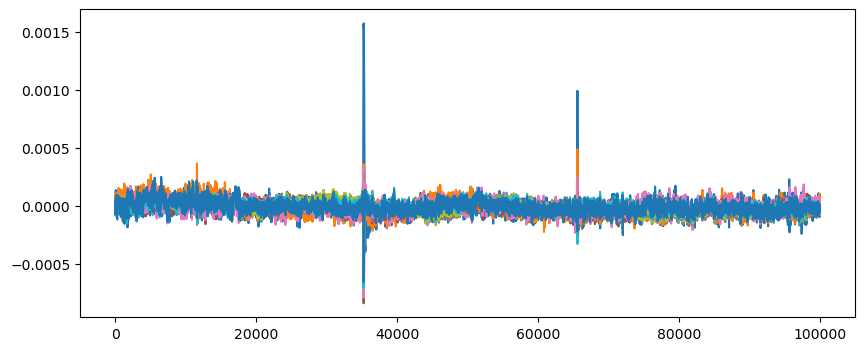

In [41]:
fig, ax=plt.subplots(figsize=(10, 4))

idx_area = df[df['AAL'] == "Temporal_Mid_R"].index
ax.plot(data[idx_area, 0:100000].T )